# Evaluate and explore CN3S

Load a saved calibration, evaluate historical simulation, and try parameters without optimization. Works offline for daily and monthly runs. Set the configuration once, then run all cells. New fits use unique IDs; `latest` also opens the existing legacy calibration. Install `pip install -e ".[notebook]"` if notebook widgets are unavailable.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from cn3s import CalibrationEvaluation, CalibrationStore, ModelPlayground

In [2]:
data_root = Path("/data/CN3S")
station_code = "56610000"
frequency = "D"
run_id = "latest"  # Or an explicit ID from the table below; legacy files use "legacy".
period = "all"  # "train", "test", or "all"

## Choose and inspect a saved run

The loaded ID, input revision, dates and solver status identify this result. `completed` does not imply solver convergence. To open another run, copy its ID into the configuration and rerun the load cell.

In [3]:
store = CalibrationStore(data_root)
store.list_runs(station_code, frequency)

,run_id,label,kind,status,created_at,input_revision,warmup_steps,objective,train_nse,test_nse,converged
0,legacy,None,None,completed,None,02c5f47f37ae4db3bb1935b6e27e9a70,10,PlainNSE,0.726448,0.646617,False


In [4]:
evaluation = CalibrationEvaluation.from_run(
    data_root, station_code=station_code, frequency=frequency, run_id=run_id,
)
evaluation.settings()

,value
run_id,legacy
label,None
kind,None
status,completed
converged,False
frequency,D
station_code,56610000
input_revision,02c5f47f37ae4db3bb1935b6e27e9a70
split_date,2023-01-02
warmup_steps,10


In [5]:
evaluation.parameters()

,value
name,Station 56610000
area,1171.813881
r0,50.320484
cn_i,9.864877
alfa,0.13147
beta,0.016159
k0,1.0
k1,0.344019
k2,0.153911
act,0


In [6]:
evaluation.coverage()

,period,calendar_steps,paired_steps,excluded_steps,evaluated_start,evaluated_end
0,train,2913,2913,0,2015-01-11,2023-01-01
1,test,731,731,0,2023-01-02,2025-01-01


## Recorded and recomputed metrics

The saved table records the original objective. Recomputed evaluation includes NSE, KGE and its components, RMSE/MAE, signed bias and calendar-weighted volume bias. Positive bias means overprediction. Baseline comparisons use common finite pairs; the first CN3S row uses all available pairs. Undefined metrics include a reason. Daily persistence uses the previous calendar day only; it is not a multi-day forecast.

In [7]:
evaluation.saved_metrics()

,period,NSE,objective,paired_steps
0,train,0.726448,0.273552,2913
1,test,0.646617,0.353383,731


In [8]:
evaluation.metrics(period)

,NSE,KGE,correlation,variability_ratio,mean_ratio,RMSE,MAE,bias,volume_bias_pct,paired_steps,undefined_reason
series,,,,,,,,,,,
CN3S (all pairs),0.717135,0.760332,0.862258,0.951722,0.809903,13.689328,8.908801,-3.486576,-19.009699,3644,
q_m3s (common pairs),0.717135,0.760332,0.862258,0.951722,0.809903,13.689328,8.908801,-3.486576,-19.009699,3644,
seasonal_climatology (common pairs),0.203641,0.223441,0.451267,0.450514,1.000461,22.969271,9.877666,0.008462,0.046138,3644,
one_day_persistence (common pairs),0.729225,0.864597,0.864598,0.999896,0.999423,13.393601,4.204997,-0.010590,-0.057739,3644,


## Flow and rainfall

Rainfall bars descend from the upper secondary axis on their forcing dates. Discharge retains ACT-adjusted response dates. Missing observations remain gaps. The split line marks the saved train/test boundary.

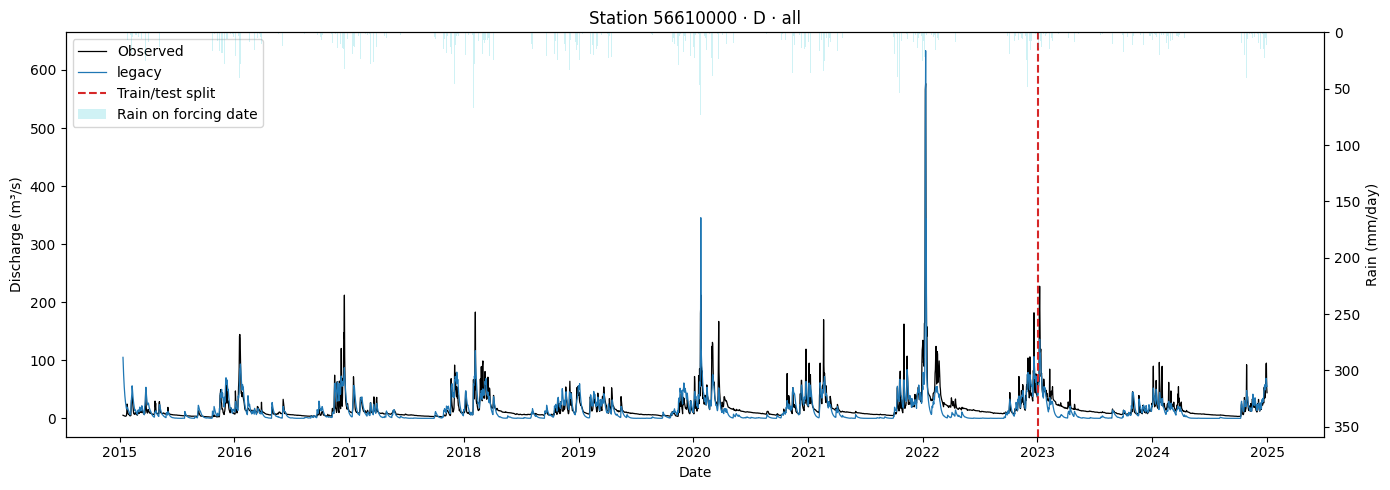

In [9]:
fig = evaluation.hydrograph(period="all", rainfall=True)

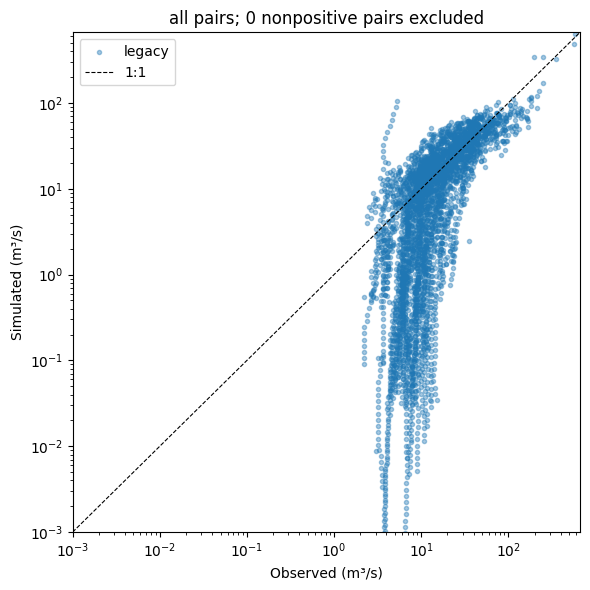

In [10]:
fig = evaluation.scatter(period, log=True)

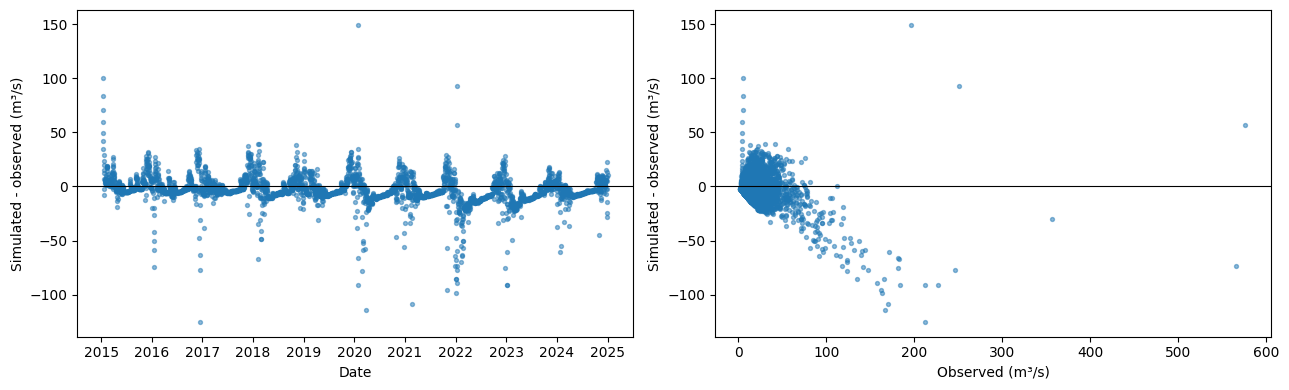

In [11]:
fig = evaluation.residuals(period)

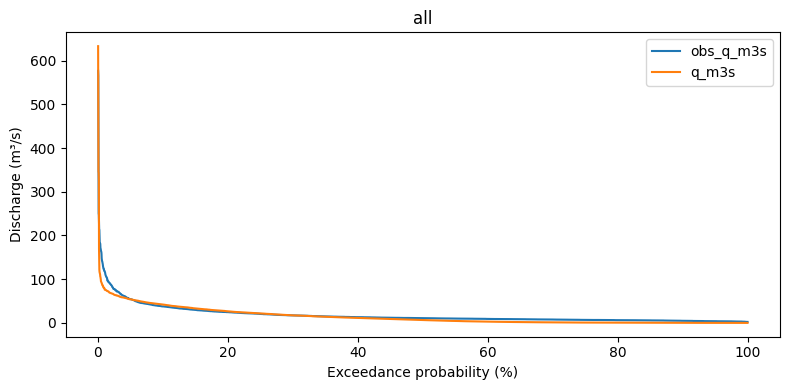

In [12]:
fig = evaluation.flow_duration(period)

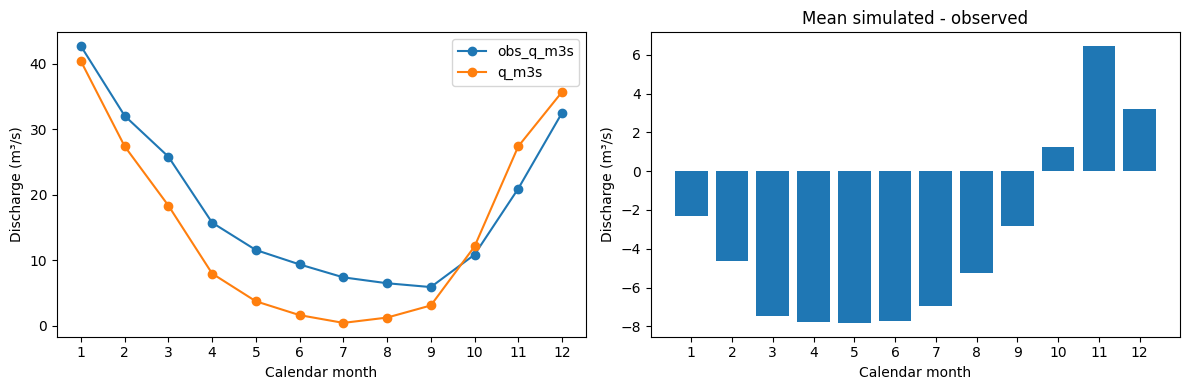

In [13]:
fig = evaluation.seasonality(period)

In [14]:
evaluation.seasonal_errors(period, by="month")

,paired_steps,bias
1,301,-2.302240
2,283,-4.653484
3,310,-7.456024
4,300,-7.762486
5,310,-7.821209
6,300,-7.734220
7,310,-6.943475
8,310,-5.236109
9,300,-2.802679
10,310,1.242005


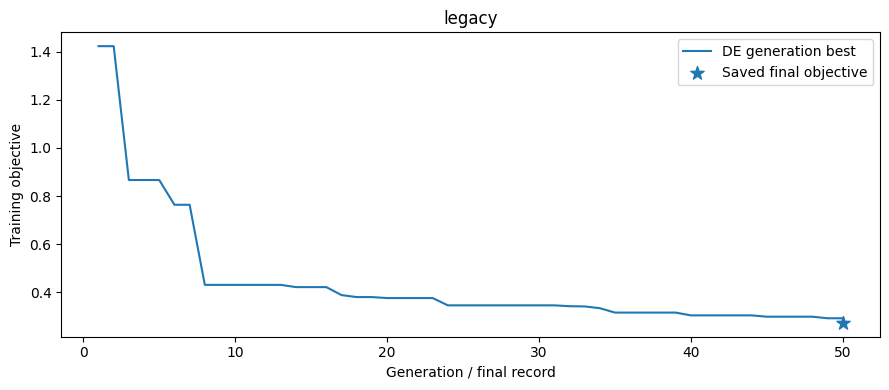

In [15]:
fig = evaluation.optimization_history()

## Play with the parameters

Edit numeric fields, then press **Run simulation**. Only one model simulation runs; daily records may take a few seconds. The saved reference, forcing and evaluation split stay fixed. The comparison uses dates available to both runs if ACT or antecedent length changes. **Reset to saved** discards the trial without recomputing.

**Save experiment** creates a separately labeled manual run, linked to its parent; it does not change the latest calibration or selected run. Repeated tuning against the test period turns it into exploratory validation. These plots evaluate observed-rainfall simulation, not forecast skill.

For a plain Python alternative, `playground.run({"k1": 0.2})` returns an evaluation object; `playground.comparison(period)` shows the comparison. The widget delegates to those same methods. Monthly ACT is fixed at zero.

In [17]:
playground = ModelPlayground(evaluation)


In [ ]:
evaluation = playground.run({"k1": 0.2})


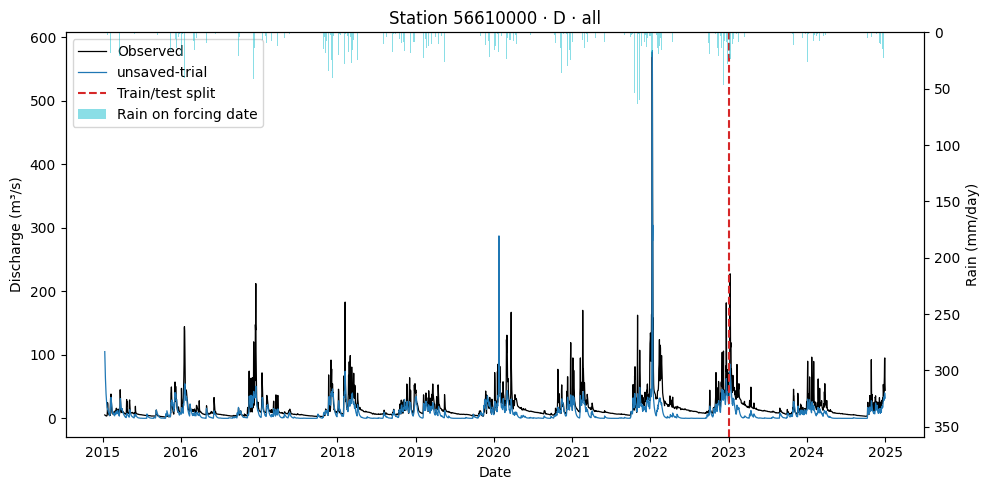

In [22]:
fig = evaluation.hydrograph(period="all", rainfall=True)

In [ ]:
playground.widget(period=period)